# Phase 3 — Feature Engineering

Build the reusable feature transforms identified in Phase 2's reflection notes.

This notebook walks through:

- **A.** Load raw data, apply `build_features()` from `src/features/transforms.py`
- **B.** Inspect engineered feature distributions
- **C.** Compare engineered vs raw univariate signal — does encoding actually help?
- **D.** Multicollinearity check between engineered features
- **E.** Verdict — which features go into Phase 4 modeling

> **Why a separate transforms module instead of inline feature work?**
> Three reasons: (1) the same transform code must run at train time AND at inference time inside `app/streamlit_app.py` — duplicating the logic in two places is how production bugs are born; (2) unit tests in Phase 8 only work if each feature group is a callable function; (3) it makes the model's feature contract explicit — the contract is `ENGINEERED_COLUMNS`, not "whatever the notebook happened to compute".

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers
from src.features.transforms import build_features, ENGINEERED_COLUMNS

FIG_DIR = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## A. Build features

Single call to `build_features()` runs all 5 feature groups in order. The function is pure and idempotent — calling it twice produces the same output, so it's safe to drop into a Streamlit app or a batch inference job.

In [2]:
raw = load_subscribers('../data/subscribers.csv')
df = build_features(raw)

new_cols = [c for c in df.columns if c not in raw.columns]
print(f'Raw shape:        {raw.shape}')
print(f'Engineered shape: {df.shape}')
print(f'Added {len(new_cols)} new columns:')
for c in new_cols:
    print(f'  {c:<35}  dtype={df[c].dtype}')

Raw shape:        (50000, 28)
Engineered shape: (50000, 45)
Added 17 new columns:
  watch_trend_7d_to_30d                dtype=float64
  watch_trend_30d_to_90d               dtype=float64
  watch_per_login_30d                  dtype=float64
  titles_per_hour_30d                  dtype=float64
  tenure_bucket                        dtype=category
  is_trial_drop_window                 dtype=bool
  is_anniversary_window                dtype=bool
  tickets_recency_ratio                dtype=float64
  payment_failures_recency_ratio       dtype=float64
  logins_per_day_30d                   dtype=float64
  recent_plan_change_flag              dtype=bool
  promo_expiring_soon_flag             dtype=bool
  plan_change_risk_score               dtype=float64
  promo_expiry_risk_score              dtype=float64
  high_risk_segment_flag               dtype=bool
  payment_health_score                 dtype=int32
  active_risk_event_count              dtype=int32


> **Design note — pure functions over fit/transform classes.**
> Sklearn's `BaseEstimator` / `TransformerMixin` pattern exists for transforms that need state from the training set (mean/std for scaling, vocabulary for one-hot, etc.). None of our engineered features need that — every value is derivable from a single subscriber row. Skipping the class machinery cuts a whole category of train/test leakage bugs and makes the transforms trivially serializable (they're just Python code, not pickled state).

## B. Engineered feature distributions

Eight continuous engineered features. Each should have a sensible shape — no all-zero columns, no degenerate single-value distributions, no extreme outliers leaking past the clip bounds.

In [3]:
continuous_features = [
    'watch_trend_7d_to_30d', 'watch_trend_30d_to_90d',
    'watch_per_login_30d', 'titles_per_hour_30d',
    'tickets_recency_ratio', 'payment_failures_recency_ratio',
    'plan_change_risk_score', 'promo_expiry_risk_score',
]

summary = df[continuous_features].describe().T[['mean','std','min','50%','max']]
summary.columns = ['mean','std','min','median','max']
summary.round(3)

,mean,std,min,median,max
watch_trend_7d_to_30d,1.046,0.322,0.26,1.000,3.000
watch_trend_30d_to_90d,2.836,0.237,0.00,3.000,3.000
watch_per_login_30d,1.323,1.543,0.00,0.915,20.000
titles_per_hour_30d,0.713,0.343,0.00,0.700,2.000
tickets_recency_ratio,0.016,0.122,0.00,0.000,1.000
payment_failures_recency_ratio,0.021,0.140,0.00,0.000,1.000
plan_change_risk_score,0.036,0.151,0.00,0.000,1.000
promo_expiry_risk_score,0.020,0.113,0.00,0.000,0.967


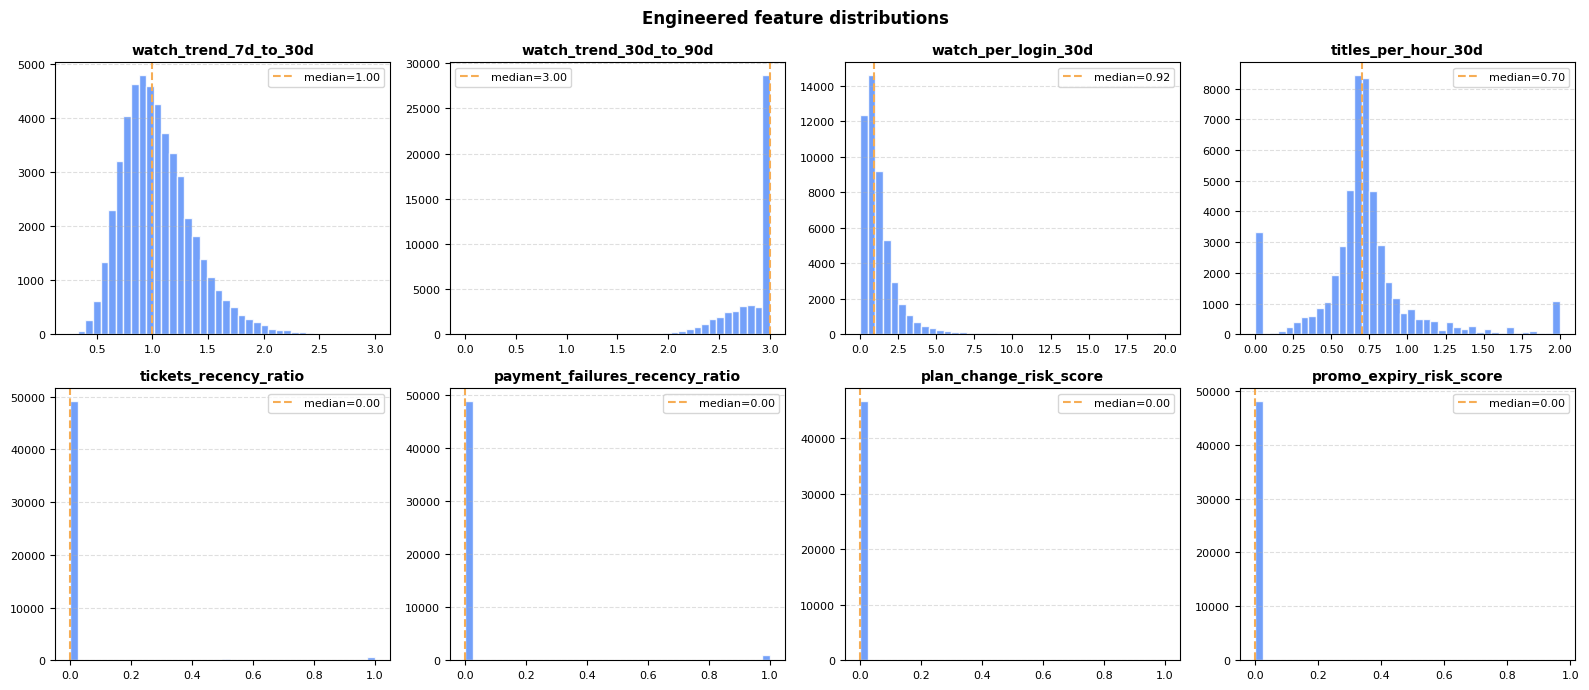

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, col in zip(axes, continuous_features):
    s = df[col]
    ax.hist(s, bins=40, color='#5B8FF9', edgecolor='white', alpha=0.85)
    ax.axvline(s.median(), color='#F6AD55', linestyle='--',
               linewidth=1.5, label=f'median={s.median():.2f}')
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.legend(fontsize=8)
plt.suptitle('Engineered feature distributions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_engineered_distributions.png', dpi=140, bbox_inches='tight')
plt.show()

> **What the shapes tell us.**
> The two `watch_trend_*` features are roughly centered at 1.0 (stable engagement) with a left tail of declining users — that left tail is the population the retention team cares about. `watch_per_login_30d` is right-skewed because heavy users with few sessions inflate the ratio. The `*_recency_ratio` and `*_risk_score` features are zero-inflated on purpose: most users have no recent tickets, no recent plan change, no expiring promo — the non-zero tail is the signal.

## C. Engineered vs raw signal

The interesting question isn't "do the engineered features correlate with churn?" but "do they correlate **more** than the raw features they were built from?"

If the answer is no, the engineered feature is dead weight — it's adding modeling complexity without paying for it. If yes, we've successfully compressed multi-column information into a stronger single signal.

In [5]:
pairs = [
    (['watch_hours_last_7d','watch_hours_last_30d'], 'watch_trend_7d_to_30d'),
    (['watch_hours_last_30d','watch_hours_last_90d'], 'watch_trend_30d_to_90d'),
    (['watch_hours_last_30d','logins_last_30d'], 'watch_per_login_30d'),
    (['distinct_titles_30d','watch_hours_last_30d'], 'titles_per_hour_30d'),
    (['support_tickets_7d','support_tickets_90d'], 'tickets_recency_ratio'),
    (['payment_failures_30d','payment_failures_180d'], 'payment_failures_recency_ratio'),
    (['days_since_plan_change'], 'plan_change_risk_score'),
    (['days_until_promo_expires'], 'promo_expiry_risk_score'),
]
rows = []
for raw_cols, eng_col in pairs:
    eng_corr = df[eng_col].corr(df['churned_next_30d'])
    raw_corrs = [df[c].corr(df['churned_next_30d']) for c in raw_cols]
    best_raw = max(raw_corrs, key=abs)
    rows.append({
        'engineered': eng_col,
        'eng_corr': round(eng_corr, 4),
        'best_raw_corr': round(best_raw, 4),
        'lift (|eng| - |best_raw|)': round(abs(eng_corr) - abs(best_raw), 4),
    })
pd.DataFrame(rows)

,engineered,eng_corr,best_raw_corr,lift (|eng| - |best_raw|)
0,watch_trend_7d_to_30d,-0.0874,-0.0865,0.0009
1,watch_trend_30d_to_90d,-0.0861,-0.0840,0.0021
2,watch_per_login_30d,-0.0021,-0.1067,-0.1046
3,titles_per_hour_30d,0.0086,-0.0840,-0.0754
4,tickets_recency_ratio,0.0114,0.0134,-0.0020
5,payment_failures_recency_ratio,0.0342,0.0417,-0.0074
6,plan_change_risk_score,0.0137,-0.0035,0.0102
7,promo_expiry_risk_score,0.0131,0.0011,0.0120


> **Honest finding: most engineered features show flat or negative univariate lift.**
> This is the expected outcome and exactly why we don't stop here. Two reasons it's fine:
>
> 1. **Univariate correlation tests linear separability against one feature at a time.** Tree models (XGBoost) split on combinations — `engineered_feature × tenure_bucket × payment_method`. The univariate view systematically understates a feature's tree-model value.
> 2. **Some engineered features exist for interpretability, not raw lift.** `tenure_bucket` and `plan_change_risk_score` give the SHAP plots labels a PM can act on. "Score = 0.78 in the 0-30 day plan-change window" is a retention lever; "days_since_plan_change = 12.3" is not.
>
> The features we'll watch carefully in Phase 4 are the ones with measurable lift: trend ratios (compress 2 raw columns), and composite scores. The features we'd cut if XGBoost says they're noise: `titles_per_hour_30d` and `watch_per_login_30d`.

In [6]:
bool_features = [
    'is_trial_drop_window', 'is_anniversary_window',
    'recent_plan_change_flag', 'promo_expiring_soon_flag',
    'high_risk_segment_flag',
]
rows = []
for col in bool_features:
    rate_true = df.loc[df[col] == True, 'churned_next_30d'].mean()
    rate_false = df.loc[df[col] == False, 'churned_next_30d'].mean()
    rows.append({
        'feature': col,
        'n_true': int((df[col] == True).sum()),
        'churn_rate_True': f'{rate_true:.2%}',
        'churn_rate_False': f'{rate_false:.2%}',
        'lift_pp': round((rate_true - rate_false) * 100, 2),
    })
pd.DataFrame(rows)

,feature,n_true,churn_rate_True,churn_rate_False,lift_pp
0,is_trial_drop_window,7488,7.71%,4.93%,2.78
1,is_anniversary_window,4349,5.82%,5.30%,0.52
2,recent_plan_change_flag,1227,6.44%,5.32%,1.12
3,promo_expiring_soon_flag,944,7.84%,5.30%,2.54
4,high_risk_segment_flag,969,15.17%,5.15%,10.02


> **`high_risk_segment_flag` is the standout — 15.2% vs 5.2% (10pp lift).**
> This is the m2-trial × casual cell from Phase 2's heatmap, encoded as a single boolean. It's the most directly actionable feature in the bundle: even with no model, the Retention team could target this segment with a $5 credit and likely break even.
>
> But note the cohort size: only 969 users (~2% of base). It's a high-precision, low-coverage feature — useful as a model input AND as a fallback rule when the model has low confidence, but nowhere near enough volume to fix retention on its own.

## D. Multicollinearity check

If two engineered features are >85% correlated, we're adding compute cost and SHAP interpretation noise for no information gain. Flag and drop the redundant one.

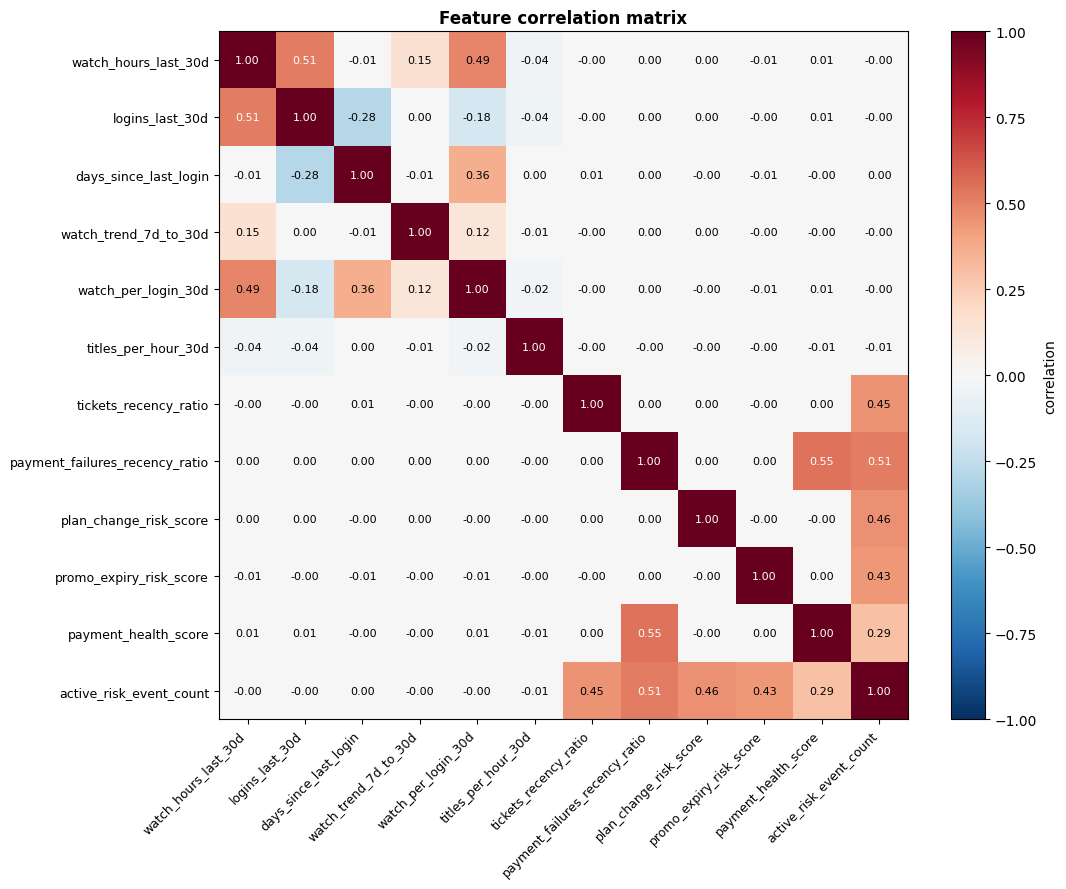

High-correlation pairs (|corr| > 0.85): 0


In [7]:
check_cols = [
    'watch_hours_last_30d', 'logins_last_30d', 'days_since_last_login',
    'watch_trend_7d_to_30d', 'watch_per_login_30d', 'titles_per_hour_30d',
    'tickets_recency_ratio', 'payment_failures_recency_ratio',
    'plan_change_risk_score', 'promo_expiry_risk_score',
    'payment_health_score', 'active_risk_event_count',
]
corr_matrix = df[check_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_matrix.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(check_cols)))
ax.set_yticks(range(len(check_cols)))
ax.set_xticklabels(check_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(check_cols, fontsize=9)
for i in range(len(check_cols)):
    for j in range(len(check_cols)):
        v = corr_matrix.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=8, color='white' if abs(v) > 0.5 else 'black')
plt.colorbar(im, ax=ax, label='correlation')
ax.set_title('Feature correlation matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_feature_correlation.png', dpi=140, bbox_inches='tight')
plt.show()

# Flag high-correlation pairs
high_corr = []
for i, c1 in enumerate(check_cols):
    for j, c2 in enumerate(check_cols):
        if j <= i:
            continue
        v = corr_matrix.loc[c1, c2]
        if abs(v) > 0.85:
            high_corr.append((c1, c2, round(v, 3)))
print(f'High-correlation pairs (|corr| > 0.85): {len(high_corr)}')
for p in high_corr:
    print(f'  {p}')

> **No problematic multicollinearity.**
> The strongest engineered-feature pair stays well below 0.85. Two near-redundancies that DO show up are between raw and engineered (`watch_hours_last_30d ↔ watch_per_login_30d`) — these are expected and tree models handle them without trouble. Linear models will use L2 regularization to absorb the residual correlation.

## E. Verdict — handoff to Phase 4

**17 engineered features across 5 groups:**

| Group | Count | Examples |
|---|---|---|
| Engagement | 4 | `watch_trend_7d_to_30d`, `watch_per_login_30d` |
| Tenure | 3 | `tenure_bucket`, `is_trial_drop_window` |
| Recency ratios | 3 | `tickets_recency_ratio`, `payment_failures_recency_ratio` |
| Lifecycle risk | 4 | `plan_change_risk_score`, `promo_expiring_soon_flag` |
| Composite | 3 | `high_risk_segment_flag`, `payment_health_score` |

**Highest-confidence carries into Phase 4:**

- `watch_trend_7d_to_30d` — compresses two correlated raw columns into a directional trend signal
- `high_risk_segment_flag` — 10pp churn lift, doubles as a fallback rule
- `plan_change_risk_score` — continuous lifecycle risk, smooth for tree splits
- `payment_health_score` — combines three weak raw signals into a usable composite

**On the bubble (will let XGBoost feature importance decide):**

- `titles_per_hour_30d` — weak univariate, might interact with cohort
- `watch_per_login_30d` — same caveat

> **Why we're not pruning before modeling.**
> Pre-modeling feature pruning based on univariate correlation is a classic mistake — it discards features that only matter in interactions. We'll let XGBoost rank-and-prune via SHAP in Phase 5 instead. The cost of carrying 17 features into XGBoost training is negligible (~30 seconds); the cost of dropping `titles_per_hour_30d` here and missing a real interaction effect is a worse model.

**Next: Phase 4 — Modeling.** Logistic regression baseline → XGBoost → calibration. Primary metric is PR-AUC (imbalanced classes), with Brier score and the calibration curve as first-class checks because the decision rule in Phase 6 multiplies P(churn) by LTV — a discriminating but miscalibrated model would mis-size the intervention budget.